# Part 2 Task A - spatial networks and planarity):


In [350]:
import pandas as pd
import osmnx as ox
import networkx as nx
import glob
import os
import re
from shapely.geometry import box

# Locate all accident data files (CSV + Excel) in the folder
folder = r"C:\Users\einob\OneDrive - King's College London\AA - Network Data Analysis"

 # Match files beginning with "20" (e.g., 2009–2019)
files = glob.glob(folder + r"\20*.csv") + glob.glob(folder + r"\20*.xlsx")

# Load each file, extract the year, and clean column names
dfs = []
for f in files:
    name = os.path.basename(f)
     # Extract year from filename (e.g., "2012")
    m = re.search(r"(20\d{2})", name)
    if not m:
        continue
    year = int(m.group(1))

    # Load file depending on extension
    if f.endswith(".csv"):
        df = pd.read_csv(f, encoding="latin1")
    else:
        df = pd.read_excel(f)

    # Clean column names BEFORE concatenation
    df = df.rename(columns=lambda x: x.strip())  # remove trailing spaces
    df = df.rename(columns={
        "Grid Ref: Easting": "Easting",
        "Grid Ref: Northing": "Northing",
        "EASTING": "Easting",
        "NORTHING": "Northing",
        "Easting ": "Easting",
        "Northing ": "Northing",
    })
    # Add year column
    df["Year"] = year
    dfs.append(df)

#Combine all years into a single DataFrame
df_acc = pd.concat(dfs, ignore_index=True)
df_acc = df_acc.loc[:, ~df_acc.columns.duplicated()] #drop duplicated columns
df_acc = df_acc.drop_duplicates() #drop duplicated rows


df_acc = df_acc.loc[:, ~df_acc.columns.duplicated()] #Then drop any remaining duplicates:

#drop rows with missing coordinates 
# 2017, 2018, and 2019 data was dropped due to this
print("Years before dropna:", df_acc["Year"].unique())

df_acc = df_acc.dropna(subset=["Easting", "Northing"])
print("Years after dropna:", (df_acc["Year"].unique()))
print("Loaded files:", files)
print("Total df_accidents:", len(df_acc))





Years before dropna: [2009 2010 2011 2012 2013 2014 2015 2017 2018 2019]
Years after dropna: [2009 2010 2011 2012 2013 2014 2015]
Loaded files: ["C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2009.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2010.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2011.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2012.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2013.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2014.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2015.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2017.csv", "C:\\Users\\einob\\OneDrive - King's College London\\AA - Network Data Analysis\\2018.csv", "C:\\Users\\einob\\OneDrive

2. Convert Easting/Northing → Latitude/Longitude

The Leeds df_accident dataset uses British National Grid (EPSG:27700).
OSMnx requires WGS84 (EPSG:4326).

This also creates a GeoDataFrame

In [351]:
import geopandas as gpd

gdf = gpd.GeoDataFrame(
    df_acc,
    geometry=gpd.points_from_xy(df_acc["Easting"], df_acc["Northing"]),
    crs="EPSG:27700" # <== OSGB36 British National Gri
).to_crs("EPSG:4326") #<== convert to WGS84 lat/lon


#Retrieve lat/lon directly from geometry
gdf["lon"] = gdf.geometry.x
gdf["lat"] = gdf.geometry.y



3. Choose a 1 km² bounding box around Leeds city centre

A 1 km × 1 km square is roughly 0.009° × 0.009°.
Let’s centre it on Leeds Train Station (a high‑df_accident area):


In [352]:
# loop through different 1 km^2 coordinates to find an area that has >=300 accidents
import numpy as np

# Rough bounding box for central Leeds
lat_min, lat_max = 53.790, 53.810
lon_min, lon_max = -1.565, -1.525

# Grid resolution - ~100 m grid spacing
step = 0.001   

lat_grid = np.arange(lat_min, lat_max, step)
lon_grid = np.arange(lon_min, lon_max, step)

#THIS FUNCTION FINDS THE 1 KM^2 THAT HAS THE MOST ACCIDENTS!
def count_accidents_in_square(gdf, lat, lon, dlat=0.0045, dlon=0.0075):
    box = gdf.cx[
        lon - dlon : lon + dlon,
        lat - dlat : lat + dlat
    ]
    return len(box)

best_count = 0
best_center = None

for lat in lat_grid:
    for lon in lon_grid:
        count = count_accidents_in_square(gdf, lat, lon)
        if count > best_count:
            best_count = count
            best_center = (lat, lon)

best_center, best_count #gives me the best coord center based on # of accidents (837)



((np.float64(53.79899999999998), np.float64(-1.5400000000000027)), 837)

In [353]:
from geopy.distance import geodesic
import geopandas as gpd

# --- CENTER POINT ---
center_lat = 53.79899
center_lon = -1.54

# --- RADIUS IN METRES ---
radius_m = 560   # 560 m radius

# --- CREATE ROAD NETWORK FROM POINT ---
G = ox.graph_from_point(
    (center_lat, center_lon),
    dist=radius_m,
    network_type="drive"
)

# --- FILTER ACCIDENTS TO THE SAME 500 m RADIUS ---
def within_radius(row):
    return geodesic(
        (center_lat, center_lon),
        (row["lat"], row["lon"])
    ).meters <= radius_m


acc_radius = gdf[gdf.apply(within_radius, axis=1)]
print("Accidents within 500 m:", len(acc_radius))


Accidents within 500 m: 751


answer the following questions:

1. What are the coordinates of the chosen area?
2. What are the characteristics of this road network? Include, at least, the spatial
diameter of the network, the average street length, node density, intersection density,
and edge density.
3. What is the average circuitry of the network? What does this tell you about the
efficiency of using roads in this area?
4. Is the network planar? Why/why not? Provide examples and argue your answer
considering the conditions of planarity. 

CREATE A GRAPH INTO GEODATAFRAMES

In [354]:
import networkx as nx
import math

# Convert graph to GeoDataFrames
nodes, edges = ox.graph_to_gdfs(G, nodes=True, edges=True)
#nodes, edges = ox.graph_to_gdfs(roads_geodataframe, nodes=True, edges=True)
# -----------------------------
# 1. SPATIAL DIAMETER (m)
# -----------------------------
lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight="length"))
spatial_diameter = max(max(d.values()) for d in lengths.values())
print("Spatial diameter (m):", spatial_diameter)

# -----------------------------
# 2. AVERAGE STREET LENGTH (m)
# -----------------------------
avg_street_length = edges["length"].mean()
print("Average street length (m):", avg_street_length)

# -----------------------------
# 3. AREA OF A 500 m RADIUS CIRCLE
# -----------------------------
# radius_m = 560
area_km2 = math.pi * (radius_m/1000)**2   # convert radius to km
print("Area (km²):", area_km2)

# -----------------------------
# 4. NODE DENSITY (nodes per km²)
# -----------------------------
node_density = len(nodes) / area_km2
print("Node density (nodes per km²):", node_density)

# -----------------------------
# 5. INTERSECTION DENSITY (per km²)
# -----------------------------
intersections = nodes[nodes["street_count"] >= 3]
intersection_density = len(intersections) / area_km2
print("Intersection density (per km²):", intersection_density)

# -----------------------------
# 6. EDGE DENSITY (km of road per km²)
# -----------------------------
total_edge_length_km = edges["length"].sum() / 1000
edge_density = total_edge_length_km / area_km2
print("Edge density (km of road per km²):", edge_density)

Spatial diameter (m): 3073.8027367100976
Average street length (m): 64.42109231927424
Area (km²): 0.9852034561657592
Node density (nodes per km²): 251.72465489024262
Intersection density (per km²): 215.18397918036868
Edge density (km of road per km²): 27.920939830424164


Average Circuitry:

The average circuitry for the network of central Leeds is 1.076. this means that the actual travel distance along roads is only about 6.7% longer than the straight line distance between connected points. Such a low circuity value indicates that the road layout in this part of central Leeds is relatively direct and efficient, with few forced detours or winding street patterns. Drivers can expect to reach destinations using shorter, more direct routes for this well-structured street grid.



In [355]:
stats = ox.basic_stats(G)
avg_circuity = stats["circuity_avg"]
print("Average circuitry:", avg_circuity)

Average circuitry: 1.0683011601651016


Is the network planar? 

Why/why not? 

Provide examples and argue your answer
considering the conditions of planarity.

The road network within the 560 m radius point has 19 non-intersecting road crossings which makes the network not planar. A planar graph must be drawable in two dimensions without any edges crossing except at shared nodes. These represent locations where one road passes over another via a bridge, flyover, or grade separated junction. In a planar graph, edges may only meet at shared endpoints, so any interior crossing without a node violates planarity. The presence of these 19 non intersecting crossings demonstrates that the central Leeds road network is non planar.

In the example below, the road network within the 500 m radius is not planar. A clear example is the crossing between Bridge Street (blue line)  and New York Rd (red line).  where New York Rd. passes over the other via overpass. In the spatial geometry, these two edges cross, but in the graph representation they do not share a node, meaning there is no intersection between them. This violates the definition of planarity, which requires that edges only meet at nodes and never cross otherwise.





In [356]:
#CODE BELOW SHOWS 19 EXAMPLES OF WHERE EDGES CROSS BUT DO NOT SHARE A NODE
import shapely

crossings = [] # holds pairs of edges that cross each other
for i, e1 in edges.iterrows():
    for j, e2 in edges.iterrows(): # loop over every pair of edges in the network
        if i >= j: # skip duplicate comparisons
            continue   
        # If geometries cross but do NOT touch at a node
        if e1.geometry.crosses(e2.geometry):
            crossings.append((i, j))

print(f"There are {len(crossings)} road crossings in this network")

#Print each road intersection within the LEEDS Network including the geometry
for idx, pair in enumerate(crossings):
    print(f"\n=== Crossing pair {idx+1} of {len(crossings)} ===")

    # unpack the two edges
    (u1, v1, k1), (u2, v2, k2) = pair

    # extract both edges
    e1 = edges.loc[(u1, v1, k1)]
    e2 = edges.loc[(u2, v2, k2)]

    print("\n--- Edge 1 ---")
    print("Road name:", e1.get("name"))
    print("Highway type:", e1.get("highway"))
    print("Length (m):", e1.get("length"))
    print("Is bridge:", e1.get("bridge"))
    print("Is tunnel:", e1.get("tunnel"))
    print("One-way:", e1.get("oneway"))
    print("Geometry:", e1.geometry)

    print("\n--- Edge 2 ---")
    print("Road name:", e2.get("name"))
    print("Highway type:", e2.get("highway"))
    print("Length (m):", e2.get("length"))
    print("Is bridge:", e2.get("bridge"))
    print("Is tunnel:", e2.get("tunnel"))
    print("One-way:", e2.get("oneway"))
    print("Geometry:", e2.geometry)



There are 26 road crossings in this network

=== Crossing pair 1 of 26 ===

--- Edge 1 ---
Road name: Regent Street
Highway type: trunk
Length (m): 196.5443943255206
Is bridge: nan
Is tunnel: nan
One-way: True
Geometry: LINESTRING (-1.5360765 53.7988377, -1.5359294 53.7989481, -1.5357935 53.7990119, -1.5357424 53.7990331, -1.5356409 53.7990752, -1.5353407 53.7991998, -1.5350475 53.7993216, -1.5345728 53.7995515, -1.5344565 53.7996121, -1.534422 53.7996301, -1.5342588 53.7997459, -1.5340704 53.7998957, -1.5339751 53.7999835, -1.5339205 53.8000377)

--- Edge 2 ---
Road name: Inner Ring Road
Highway type: motorway
Length (m): 275.7512019134588
Is bridge: yes
Is tunnel: nan
One-way: True
Geometry: LINESTRING (-1.5316365 53.7993792, -1.5320531 53.7994595, -1.5333813 53.799715, -1.5343084 53.7998896, -1.535634 53.8001379)

=== Crossing pair 2 of 26 ===

--- Edge 1 ---
Road name: Regent Street
Highway type: trunk
Length (m): 196.5443943255206
Is bridge: nan
Is tunnel: nan
One-way: True
Geomet

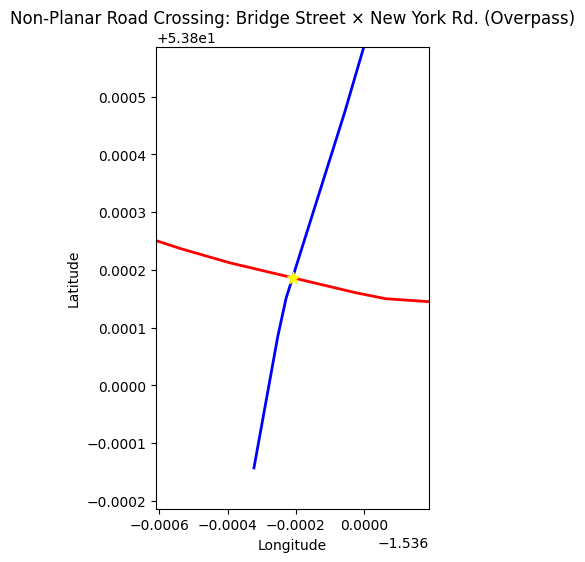

In [357]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# --- Define the two geometries exactly as given ---
edge1_geom = LineString([
    (-1.5363235, 53.7998548),
    (-1.5362528, 53.8000851),
    (-1.5362286, 53.8001508),
    (-1.5360568, 53.8004728),
    (-1.5359862, 53.8006153),
    (-1.5359274, 53.8007617)
])

edge2_geom = LineString([
    (-1.535634, 53.8001379),
    (-1.5359362, 53.8001501),
    (-1.5360246, 53.8001605),
    (-1.5363942, 53.8002124),
    (-1.5365369, 53.8002367),
    (-1.5368782, 53.8003024),
    (-1.5373544, 53.8003918),
    (-1.5379638, 53.8005033),
    (-1.5384444, 53.8005996),
    (-1.5389416, 53.8007298),
    (-1.5389884, 53.8007422),
    (-1.5391871, 53.8007797),
    (-1.53926, 53.8007952)
])

# --- Compute the crossing point ---
cross_pt = edge1_geom.intersection(edge2_geom)

# --- Build GeoDataFrames for plotting ---
gdf_edges = gpd.GeoDataFrame(
    {
        "name": ["Bridge Street", "Motorway Link"],
        "geometry": [edge1_geom, edge2_geom]
    },
    crs="EPSG:4326"
)

gdf_cross = gpd.GeoDataFrame(
    {"geometry": [cross_pt]},
    crs="EPSG:4326"
)

# --- Create a small bounding box around the crossing ---
buffer = 0.0004   # ~40m radius
minx, miny, maxx, maxy = cross_pt.buffer(buffer).bounds

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 6))

gdf_edges.plot(ax=ax, linewidth=2, color=["blue", "red"])
gdf_cross.plot(ax=ax, color="yellow", markersize=80, marker="*", zorder=5)

ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

ax.set_title("Non‑Planar Road Crossing: Bridge Street × New York Rd. (Overpass)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

Edge 1
- Name: Regent Street
- Type: trunk road
- Speed: 30 mph
- Ref: A61
- Geometry: a LINESTRING running roughly through the centre of your study area
- No bridge/tunnel tag → it’s at ground level


Edge 2
- Name: Inner Ring Road
- Type: motorway
- Speed: 40 mph
- Ref: A64(M)
- Geometry: a LINESTRING that crosses above Regent Street
- Tunnel: yes → this segment is grade‑separated


 5. Visualise df_accidents + road network


# Task B (road accidents):

 Plot the distribution of road accidents on your road network and visualise this

“To compare accident patterns over time, I plotted each year’s accidents (2009–2015) in a grid of maps. Each subplot shows the road network within the 500 m radius and the accidents that occurred in that year.
The grid layout makes it easy to observe that accident locations are consistently concentrated along Regent Street (A61) and near the junctions connecting to the A64(M) Inner Ring Road. Although the exact points vary slightly year‑to‑year, the overall spatial pattern remains stable, indicating persistent high‑risk locations.”





In [358]:
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt
"""
Function that extracts spaghetti accident/points from the geometries
Returns a GeoDataFrame of accidents snapped on to the road network
"""
def extract_snapped_points(net, pp_name, crs="EPSG:4326"):
    pp = net.pointpatterns[pp_name]

    arc_ids = pp.obs_to_arc          # arc tuple for each point, e.g. (0, 1)
    dists = pp.dist_snapped          # distance along arc
    point_ids = list(range(len(pp.points)))  # IDs = index order

    snapped_points = []

    for pid, arc, dist in zip(point_ids, arc_ids, dists):
        # arc endpoints (vertex IDs)
        u, v = arc

        # Get coordinates of the arc endpoints
        coords = [
            net.vertex_coords[u],
            net.vertex_coords[v]
        ]

        line = LineString(coords)  # Build the arc as a LineString
        snapped_pt = line.interpolate(dist) # Interpolate the snapped point along the arc

        snapped_points.append({ # Store attributes + geometry
            "id": pid,
            "arc": arc,
            "dist": dist,
            "geometry": snapped_pt
        })
    # Return as a GeoDataFrame
    return gpd.GeoDataFrame(snapped_points, geometry="geometry", crs=crs)

"""
Plots the spaghetti network arcs and overlays the snapped accident points.
Used for visually validating that snapping worked correctly.
"""
def plot_network_with_accidents(net, snapped_acc, figsize=(10, 10)):
    fig, ax = plt.subplots(figsize=figsize)

    # --- Plot each arc in the network ---
    for u, v in net.arcs:
        x1, y1 = net.vertex_coords[u]
        x2, y2 = net.vertex_coords[v]
        ax.plot([x1, x2], [y1, y2], color="black", linewidth=0.5)

    # --- Plot snapped accidents ---
    snapped_acc.plot(ax=ax, marker = "x",color="red", markersize=8, alpha=0.7)

    ax.set_aspect("equal")
    ax.set_title("Network with Snapped Accident Points")
    plt.show()



In [359]:
import spaghetti
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt

# Build network from road segments
roads_gdf = edges.copy()

#build the spaghetti Network:
net_spag = spaghetti.Network(in_data=roads_gdf)

# Create point geometry from lon/lat
acc_radius["geometry"] = gpd.points_from_xy(acc_radius.lon, acc_radius.lat, crs="EPSG:4326")

# Reproject to match the network CRS
# acc_radius contains the unsnapped map
acc_radius = acc_radius.to_crs(roads_gdf.crs)

# Save to temporary shapefile
acc_radius.to_file("acc_points.shp")

# Snap accidents to the nearest road segment
net_spag.snapobservations("acc_points.shp", "accidents", attribute=True)


# Use above function to extract the snapped points
snapped_acc = extract_snapped_points(net_spag, "accidents")



C:\Users\einob\AppData\Local\Temp\ipykernel_14748\97825113.py:20: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  acc_radius.to_file("acc_points.shp")
c:\Users\einob\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Reference Number' to 'Reference'
  ogr_write(
c:\Users\einob\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Number of Vehicles' to 'Number of'
  ogr_write(
c:\Users\einob\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Accident Date' to 'Accident D'
  ogr_write(
c:\Users\einob\AppData\Local\Programs\Python\Python311\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Time (24hr)' to 'Time (24hr'
  ogr_write(
c:\Users\einob\AppData\Local\Programs\Pytho

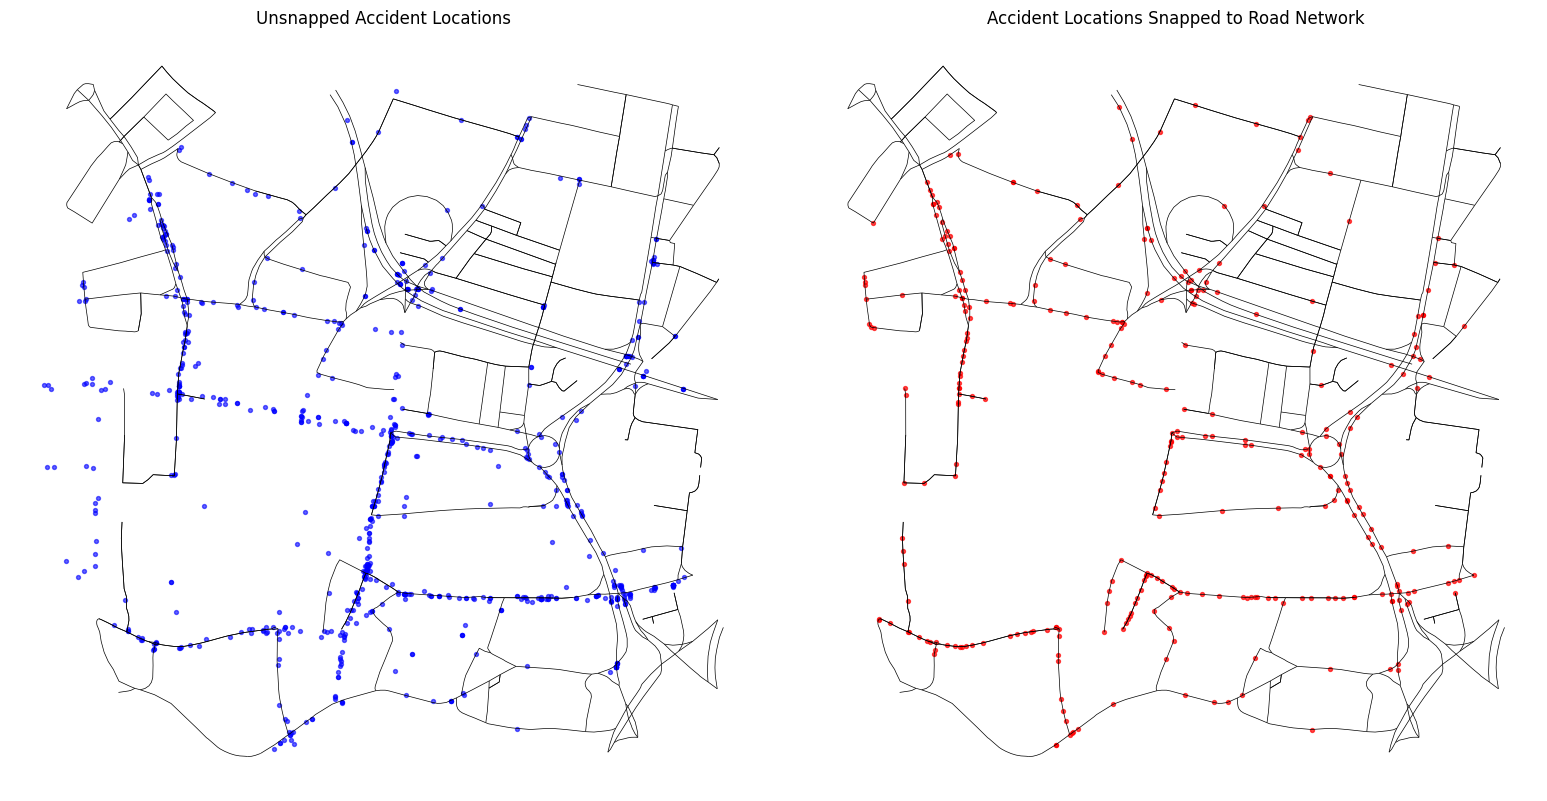

In [360]:
import matplotlib.pyplot as plt
#PLOT BOTH UNSNAPPED AND SNAPPED ACCIDENTS TO THE NETWORK

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# -----------------------------
# LEFT: Unsnapped accident points
# -----------------------------
roads_gdf.plot(ax=axes[0], color="black", linewidth=0.5)
acc_radius.plot(ax=axes[0], color="blue", markersize=8, alpha=0.6)

axes[0].set_title("Unsnapped Accident Locations")
axes[0].set_axis_off()

# -----------------------------
# RIGHT: Snapped accident points
# -----------------------------
roads_gdf.plot(ax=axes[1], color="black", linewidth=0.5)
snapped_acc.plot(ax=axes[1], color="red", markersize=8, alpha=0.7)

axes[1].set_title("Accident Locations Snapped to Road Network")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()


2. Investigate whether a high number of accidents on one road correlates with a high
number on connecting roads.

Compute the Network K-Function

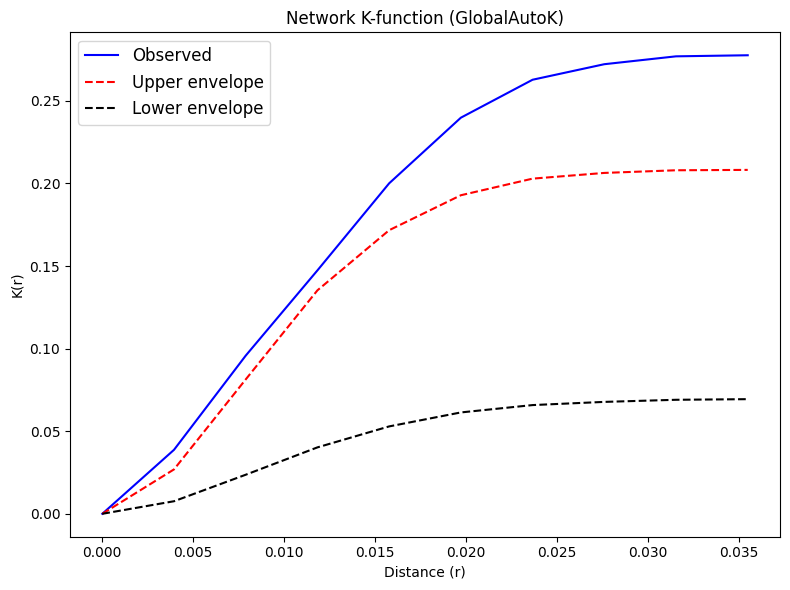

   distance_r  observed_K  upper_envelope  lower_envelope
0    0.000000    0.000000        0.000000        0.000000
1    0.003940    0.038745        0.026890        0.007606
2    0.007881    0.095779        0.081368        0.023655
3    0.011821    0.147391        0.135313        0.040217
4    0.015761    0.200092        0.171709        0.052909
5    0.019702    0.239835        0.192876        0.061372
6    0.023642    0.262812        0.202930        0.065825
7    0.027582    0.272213        0.206389        0.067755
8    0.031523    0.276980        0.207997        0.069031
9    0.035463    0.277630        0.208225        0.069408


In [361]:

# Extract the point pattern of accidents stored in the spaghetti network
pp_acc = net_spag.pointpatterns['accidents']
# GlobalAutoK computes the network K-function where:
    # - nsteps: number of distance increments
    # - permutations: number of Monte Carlo simulations for envelopes
kfun = net_spag.GlobalAutoK(pp_acc, nsteps=10, permutations=99)

# ------------------------------------------------------------
# Plot the observed K-function and simulation envelopes
# ------------------------------------------------------------
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(kfun.xaxis, kfun.observed, "b-", label="Observed")
ax.plot(kfun.xaxis, kfun.upperenvelope, "r--", label="Upper envelope")
ax.plot(kfun.xaxis, kfun.lowerenvelope, "k--", label="Lower envelope")

ax.legend(loc="best", fontsize="large")
ax.set_xlabel("Distance (r)")
ax.set_ylabel("K(r)")
ax.set_title("Network K-function (GlobalAutoK)")

fig.tight_layout()
plt.show()

k_table = pd.DataFrame({
    "distance_r": kfun.xaxis,
    "observed_K": kfun.observed,
    "upper_envelope": kfun.upperenvelope,
    "lower_envelope": kfun.lowerenvelope
})
print(k_table)


| distance_r | observed_K | upper_envelope | lower_envelope |
|-----------:|-----------:|----------------:|----------------:|
| 0.000000   | 0.000000   | 0.000000        | 0.000000        |
| 0.003940   | 0.035956   | 0.025894        | 0.007261        |
| 0.007881   | 0.087327   | 0.075938        | 0.021716        |
| 0.011821   | 0.131860   | 0.120606        | 0.035671        |
| 0.015761   | 0.178559   | 0.151355        | 0.046300        |
| 0.019702   | 0.211100   | 0.168537        | 0.053401        |
| 0.023642   | 0.230125   | 0.176268        | 0.057256        |
| 0.027582   | 0.236851   | 0.178514        | 0.058661        |
| 0.031523   | 0.239674   | 0.179694        | 0.059536        |
| 0.035463   | 0.240051   | 0.180041        | 0.060013        |

Compute Moran's I

In [362]:
from esda import Moran
import numpy as np
import networkx as nx
from libpysal.weights import W

# Each accident has been snapped to an arc ID. this counts how many per arc
acc_counts = snapped_acc.groupby("arc").size().rename("acc_count")

#build the geoDataFrame for the arc
# Convert each arc (u, v) into a LineString using the vertex coordinates
arc_df = gpd.GeoDataFrame({
    "arc": list(net_spag.arcs),
    "geometry": [
        LineString([net_spag.vertex_coords[u], net_spag.vertex_coords[v]])
        for (u, v) in net_spag.arcs
    ]
}, crs=roads_gdf.crs)

# Attach accident counts to each arc (fill missing with zero)
arc_df = arc_df.merge(acc_counts, on="arc", how="left")
arc_df["acc_count"] = arc_df["acc_count"].fillna(0)

# BUILD ADJACENCY BETWEEN ARCS
# Nodes = arcs; edges = arcs that share a vertex
G_arcs = nx.Graph()

# Add arcs as nodes
for arc in net_spag.arcs:
    G_arcs.add_node(arc)

# Connect arcs that share a vertex
# Two arcs are adjacent if they share either endpoint
for arc1 in net_spag.arcs:
    u1, v1 = arc1
    for arc2 in net_spag.arcs:
        if arc1 == arc2:
            continue
        u2, v2 = arc2
        if u1 in arc2 or v1 in arc2:
            G_arcs.add_edge(arc1, arc2)


#Convert adjacency graph to PySAL spatial weights
w = W.from_networkx(G_arcs)

# Response variable: accident count per arc
y = arc_df["acc_count"].values

#Compute Moran's I for spatial autocorrelation
moran = Moran(y, w)

print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)





Moran's I: 0.29060412611297354
p-value: 0.001


3. Investigate whether accidents happen nearer to intersections or partway along roads. Consider this as asking at what fraction of the road length away from the nearest intersection do accidents typically occur.

First need to extract road geometries and assign it to the snapped_acc geometry by computing the nearest road for each accident.

In [363]:
from shapely.ops import nearest_points
import numpy as np

# Extract road geometries as a list
road_geoms = roads_gdf.geometry.values
road_osmids = roads_gdf.osmid.values

nearest_osmids = []
nearest_lines = []

for point in snapped_acc.geometry:
    # compute distances to all roads
    dists = np.array([point.distance(line) for line in road_geoms])
    idx = dists.argmin()
    
    nearest_osmids.append(road_osmids[idx])
    nearest_lines.append(road_geoms[idx])

snapped_acc["nearest_osmid"] = nearest_osmids
snapped_acc["road_geom"] = nearest_lines
snapped_acc.columns



Index(['id', 'arc', 'dist', 'geometry', 'nearest_osmid', 'road_geom'], dtype='str')

Then we can compute the fractional Distance along the real road geometry of Leeds

In [364]:
#Need to Compute the fractional distance

from shapely.geometry import Point
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString

fractions = []

for idx, row in snapped_acc.iterrows():
    point = row.geometry
    line = row.road_geom   
    
    d_along = line.project(point)
    L = line.length
    d_nearest = min(d_along, L - d_along)
    
    fractions.append(d_nearest / L)

snapped_acc["fraction_to_intersection"] = fractions
snapped_acc["fraction_to_intersection"].describe()





count    320.000000
mean       0.220777
std        0.155548
min        0.000000
25%        0.086839
50%        0.218692
75%        0.344147
max        0.499207
Name: fraction_to_intersection, dtype: float64

# Part C (Voronoi Diagrams)

1. Select the initial set of 4 cell seed points. For this, you can use several criteria, such as being far away from frequent accident roads, being close to public transport, being evenly spread, etc. (explain your choice in the report). 

For this I will use "being close to public transportation": “To maximise accessibility for residents, seed points were chosen near major public transport hubs. This ensures that each marathon region is anchored by a location that is easy to reach by bus or rail.”


In [365]:
from sklearn.cluster import KMeans
import numpy as np
from shapely.geometry import Point
import geopandas as gpd


G = ox.graph_from_place(
    "Leeds, West Yorkshire, UK",
    network_type="drive"
)
#convert lat/lon to planar coordinates
G_proj = ox.project_graph(G, to_crs="EPSG:27700")



#get node coordinates
x_values = nx.get_node_attributes(G_proj, "x")
y_values = nx.get_node_attributes(G_proj, "y")

transport_hubs = { #(lat,lon) format
    "Leeds Station": (53.7952, -1.5474),
    "Micklefield Station": (53.7889, -1.3267),
    "Horsforth station": (53.8476, -1.6300),
    "Garforth station": (53.8, -1.38)
}


#hub_points = [Point(lon, lat) for lat, lon in transport_hubs.values()]

hub_points = []
for lat, lon in transport_hubs.values():
    # Point(x, y) = Point(lon, lat)
    hub_points.append(Point(lon, lat))

hubs_gdf = gpd.GeoDataFrame(
    {"name": list(transport_hubs.keys())},
    geometry=hub_points,
    crs="EPSG:4326"
).to_crs("EPSG:27700")

seed_points = []

#snaps the transport hubs to the leeds network
for pt in hubs_gdf.geometry:
    nearest_node = ox.distance.nearest_nodes(G_proj, pt.x, pt.y)
    x = G_proj.nodes[nearest_node]["x"]
    y = G_proj.nodes[nearest_node]["y"]
    seed_points.append(Point(x, y))



2. Visualise the cells yield by your selection of seed points in a Voronoi diagram. What kind of Voronoi diagram (edge planar, node network, or edge points network) is most useful for this problem, and why? 

In [366]:
import numpy as np
from shapely.geometry import Polygon, Point, LineString
from shapely.ops import unary_union
from scipy.spatial import Voronoi

def station_voronoi_maker(vor, radius):
    """
    Convert a SciPy Voronoi diagram into finite polygons by replacing
    the leeds region with large polygons. This is used to build
    Voronoi areas for the Leeds train stations.
    """
    new_regions = [] # initialize List of reconstructed regions (each is a list of vertex indices)
    new_vertices = vor.vertices.tolist() # Start with the original Voronoi vertices;

    center = vor.points.mean(axis=0)
    if vor.points.shape[0] == 0:
        return [], []

    # If no radius is provided, compute a bounding radius based on data extent
    if radius is None: 
        radius = vor.points.ptp().max() * 2

    # Build a mapping of all ridges (edges) touching each point.
    # For each station p1, store all neighbouring stations p2 and
    # the corresponding Voronoi vertices (v1, v2) defining the ridge.
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Double for-loop for Reconstruct each Voronoi region in the SAME order as vor.points.
    # If a region is finite, keep it. If it contains -1 (infinite),
    # extend its open edges outward to a large radius.
    for p1, region_index in enumerate(vor.point_region):
        region = vor.regions[region_index] # Region is a list of vertex indices (may contain -1)
        
        if -1 not in region: # If region is already finite, keep it unchanged
            new_regions.append(region)
            continue

        # Otherwise, rebuild the infinite region
        ridges = all_ridges[p1]
        new_region = [v for v in region if v != -1] # Keep only the finite vertices for now

        # For each ridge touching this point, extend infinite edges.
        for p2, v1, v2 in ridges: 
            if v2 < 0: # Ensure v2 is the finite vertex and v1 is the infinite one
                v1, v2 = v2, v1
            if v1 >= 0: # If both vertices are finite, nothing to extend
                continue

            # Compute direction of infinite ray
            # Ensure v2 is the finite vertex and v1 is the infinite one
            t = vor.points[p2] - vor.points[p1]
            t = np.array([-t[1], t[0]])  # perpendicular

            midpoint = vor.points[[p1, p2]].mean(axis=0) # Midpoint of the ridge between the two stations
            direction = np.sign(np.dot(midpoint - center, t)) * t # Choose the direction that points OUTWARD from the diagram centre
            far_point = vor.vertices[v2] + direction * radius # Extend the finite vertex v2 far outward along this direction

            # Add this new far-away vertex to the global list
            new_vertices.append(far_point.tolist())
            # Add the index of this new vertex to the region
            new_region.append(len(new_vertices) - 1)

        new_regions.append(new_region) # Store the completed finite region

    # Return all finite regions and the updated vertex array
    return new_regions, np.asarray(new_vertices)

Extract station coordinates and build the raw Voronoi diagram

In [367]:
# Convert Shapely Point geometries into a NumPy array of (x, y) coordinates
coords = np.array([(p.x, p.y) for p in hubs_gdf.geometry])
# Compute the Voronoi diagram for the station locations
vor = Voronoi(coords)

# Convert infinite Voronoi regions into finite polygons using above definition
regions, vertices = station_voronoi_maker(vor, radius=1e6)

# Get Leeds boundary
leeds_boundary = ox.geocode_to_gdf("Leeds, West Yorkshire, UK").to_crs("EPSG:27700")

# Extract the coordinates of the vertices belonging to this region
# and Create a Shapely polygon for the region
vor_polys = []
for region in regions: #creates polygon for each station
    polygon = vertices[region]
    vor_polys.append(Polygon(polygon))

#CLIP POLYGONS TO LEEDS
# Merge boundary geometry into a single polygon
boundary_poly = leeds_boundary.geometry.union_all() 
# Keep only graph nodes that fall inside the Leeds boundary
nodes_to_keep = [
    n for n, data in G_proj.nodes(data=True)
    if boundary_poly.contains(Point(data["x"], data["y"]))
]
G_proj = G_proj.subgraph(nodes_to_keep).copy() # Restrict the graph to the nodes inside Leeds

edges_to_remove = []
for u, v, data in G_proj.edges(data=True):
    geom = data.get("geometry")

    # Remove edges whose line geometry is not fully contained in Leeds
    if geom is not None and not boundary_poly.contains(geom):
        edges_to_remove.append((u, v))

# removes edges from the graph that are not in LEEDS
G_proj.remove_edges_from(edges_to_remove)

# Clip Voronoi polygons to the Leeds boundary
clipped_cells = [
    poly.intersection(boundary_poly)
    for poly in vor_polys
]

# builds the clipped Voronoi Cells in Leeds
vor_gdf = gpd.GeoDataFrame(
    {"geometry": clipped_cells},
    crs="EPSG:27700"
)



In [368]:
#this is how the different stations are mapped in the geoDataFrame
hubs_gdf.describe

<bound method NDFrame.describe of                   name                       geometry
0        Leeds Station   POINT (429911.504 433304.98)
1  Micklefield Station  POINT (444456.063 432719.266)
2    Horsforth station  POINT (424440.084 439103.494)
3     Garforth station  POINT (440933.805 433922.265)>

VISUALIZE PLANAR VORONOI DIAGRAM BASED ON STATIONS IN LEEDS:
- 0        Leeds Station - (429911.504 433304.98)
- 1  Micklefield Station - (444456.063 432719.266)
- 2    Horsforth station - (424440.084 439103.494)
- 3     Garforth station - (440933.805 433922.265)

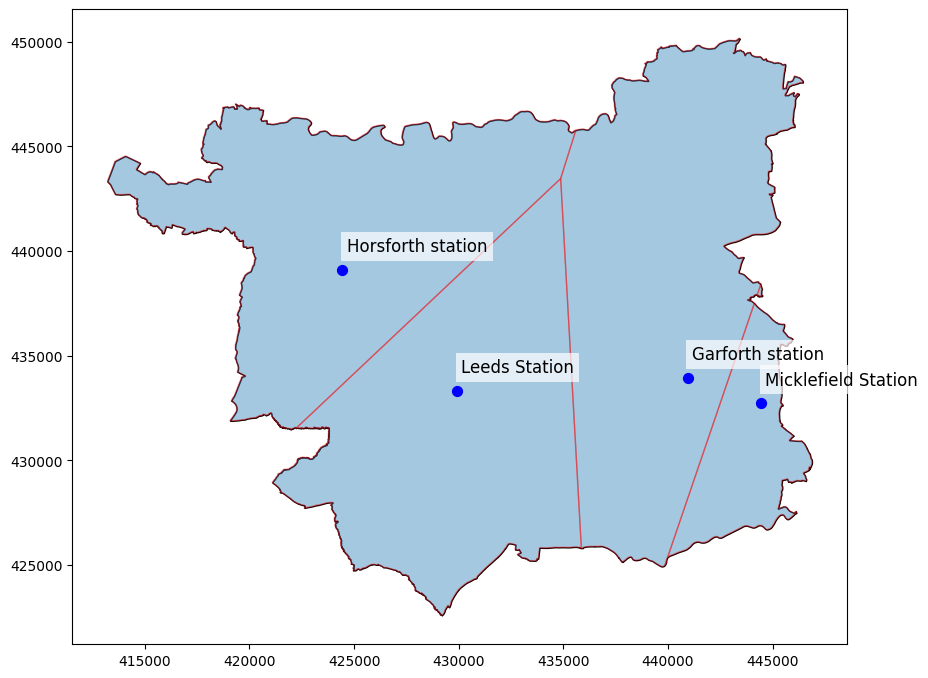

In [369]:
#VISUALIZE PLANAR VORONOI DIAGRAM

hubs_gdf["label"] = hubs_gdf["name"]

ax = leeds_boundary.plot(color="white", edgecolor="black", figsize=(10,10))
vor_gdf.plot(ax=ax, alpha=0.4, edgecolor="red")
hubs_gdf.plot(ax=ax, color="blue", markersize=50)
for idx, row in hubs_gdf.iterrows():
    x, y = row.geometry.x, row.geometry.y
    ax.text(
        x + 200, y + 700,          # slight offset so text doesn't overlap the dot
        row["label"],
        fontsize=12,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )



# the blue dots are the seed points/public transportation stations
# the red lines are the voronoi edges/boundaries between the cells

Because the mayor of Leeds wants to divide the city into “various areas” for a Marathon it makes most sense to partition the geographic space of Leeds rather than the nodes and edges of the network. To visualize this, I generated a planar Voronoi diagram using the four transport stations. 
Because marathon routes aren’t shortest-path problems, it wouldn’t make sense to construct a Voronoi diagram around the node-network and edge-points which define distance in terms of shortest paths along the road graph. Because of this, a planar Voronoi diagram is the most suitable choice for the city.


Key:
- 0        Leeds Station   POINT (429911.504 433304.98)
- 1  Micklefield Station  POINT (444456.063 432719.266)
- 2    Horsforth station  POINT (424440.084 439103.494)
- 3     Garforth station  POINT (440933.805 433922.265)

Find 2 or 3 cells for which you can find at least one path (or more, if possible) that is

(a) approximately 42 km long, and 

(b) finishes at the same point where it starts. 

Visualise both the cells and the found paths. 

This "find_multiple_loops_in_cell" function retrieves multiple valid paths within ONE Voronoi cell.
It does NOT mirror out-and-back paths so 
- path A: start → target
- path B: target → start

are DIFFERENT ROUTES

In [370]:
import networkx as nx
import random
from shapely.geometry import Point, LineString
import osmnx as ox

def path_length(G, path):
    return sum(G[u][v][0]["length"] for u, v in zip(path[:-1], path[1:]))

def route_to_linestring(G, route):
    coords = [(G.nodes[n]["x"], G.nodes[n]["y"]) for n in route]
    return LineString(coords)

def find_multiple_loops_in_cell(
    G_proj,
    cell_geom,
    hub_point,
    target_distance=42000,
    trials_per_loop=5000,
    max_loops=3,
    min_distance=38000,
    route_difference_threshold=0.15
):
    """
    Find multiple closed loops (~42 km) inside ONE Voronoi cell.
    Loops do NOT need to retrace the same road.
    """

    # 1. Extract nodes inside the cell
    nodes_in_cell = [
        n for n, data in G_proj.nodes(data=True)
        if cell_geom.contains(Point(data["x"], data["y"]))
    ]

    G_vor = G_proj.subgraph(nodes_in_cell).copy()
    if len(G_vor.nodes) == 0:
        return []

    # Compute distances from hub point to all nodes inside the cell
    start_node = ox.distance.nearest_nodes(G_proj, hub_point.x, hub_point.y)
    if start_node not in G_vor.nodes:
        start_node = list(G_vor.nodes())[0]


    nodes_list = list(G_vor.nodes())
    found_loops = []

    # 3. Try to find several loops
    for loop_index in range(max_loops):

        best_route, best_len, best_diff = None, None, 1e12

        for _ in range(trials_per_loop):
            target = random.choice(nodes_list)

            # Find the path to the farthest point
            # shortest path start → target
            try:
                out_path = nx.shortest_path(G_vor, start_node, target, weight="length")
            except nx.NetworkXNoPath:
                continue

            # find the way back:
            # shortest path target → start (may be different!)
            try:
                back_path = nx.shortest_path(G_vor, target, start_node, weight="length")
            except nx.NetworkXNoPath:
                continue

            # compute lengths
            out_len = path_length(G_vor, out_path)
            back_len = path_length(G_vor, back_path)
            total_len = out_len + back_len
            diff = abs(total_len - target_distance)

            # accept if larger than min distance (38,000) and closer to 42 km
            if total_len > min_distance and diff < best_diff:
                best_diff = diff
                best_len = total_len
                best_route = out_path + back_path[1:]  # avoid duplicate target node

        if best_route is None:
            break

        # convert to geometry
        geom = route_to_linestring(G_vor, best_route)

        # This part avoids near-duplicate loops
        too_similar = False
        for prev in found_loops:
            if geom.hausdorff_distance(prev["geometry"]) < route_difference_threshold * 1000:
                too_similar = True
                break

        if not too_similar:
            found_loops.append({
                "route": best_route,
                "length": best_len,
                "geometry": geom
            })

    return found_loops



In [371]:

#CODE FOR PLOTTING THESE LOOPS ON THE DIAGRAM
import matplotlib.pyplot as plt
import geopandas as gpd

def plot_loops_for_cell(cell_index, vor_gdf, hubs_gdf, loops, leeds_boundary, G_proj):
    """
    Visualise:
    - Leeds boundary
    - All Voronoi cells
    - Highlighted cell
    - All loops found inside that cell (each in a different colour)
    - Hub point + label
    """
    cell_geom = vor_gdf.geometry.iloc[cell_index]
    hub_point = hubs_gdf.geometry.iloc[cell_index]
    hub_label = hubs_gdf["label"].iloc[cell_index]

    fig, ax = plt.subplots(figsize=(12, 12))

    # 1. Leeds boundary
    leeds_boundary.plot(ax=ax, alpha=0.2, edgecolor="black")

    # 2. Road network
    ox.plot_graph(
        G_proj,
        ax=ax,
        node_size=0,
        edge_color="gray",
        edge_linewidth=0.5,
        show=False,
        close=False
    )

    # 3. Voronoi cells
    vor_gdf.plot(ax=ax, alpha=0.3, edgecolor="red")

    # 4. Highlight selected cell
    cell_geom = vor_gdf.geometry.iloc[cell_index]
    gpd.GeoSeries([cell_geom], crs=vor_gdf.crs).plot(
        ax=ax, color="lightblue", alpha=0.4, edgecolor="blue", linewidth=2
    )

    # 5. Plot loops (each in different colour)
    colours = ["red", "green", "purple", "orange", "brown", "cyan"]
    for i, loop in enumerate(loops):
        gpd.GeoSeries([loop["geometry"]], crs=vor_gdf.crs).plot(
            ax=ax, color=colours[i % len(colours)], linewidth=2, label=f"Loop {i+1}"
        )

    # 6. Plot hubs
    hubs_gdf.plot(ax=ax, color="blue", markersize=60)

    # 7. Label hubs
    for idx, row in hubs_gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        ax.text(
            x + 200, y + 700,          # slight offset so text doesn't overlap the dot
            row["label"],
            fontsize=12,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

    ax.set_title(f"Hub {cell_index}: Marathon Loops")
    ax.set_axis_off()
    ax.legend()
    plt.show()



In [373]:
#Valid Marathon loops For Cell 0 (Leeds Station)
cell_index = 0   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_gdf.geometry.iloc[cell_index]

loops_cell_0 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(loops_cell_0)} loops in cell {cell_index}")

for loop in loops_cell_0:
    print(loop["length"])

Found 0 loops in cell 0


In [ ]:
#Valid Marathon loops For Cell 1 (Micklefield Station)
cell_index = 1   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_gdf.geometry.iloc[cell_index]

loops_cell_1 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(loops_cell_1)} loops in cell {cell_index}")

for loop in loops_cell_1:
    print(loop["length"])



Found 0 loops in cell 1


In [ ]:
#Valid Marathon loops For Cell 2 (Horsforth station)
cell_index = 2   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_gdf.geometry.iloc[cell_index]

loops_cell_2 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(loops_cell_2)} loops in cell {cell_index}")

for loop in loops_cell_2:
    print(loop["length"])

Found 0 loops in cell 2


In [ ]:
#Valid Marathon loops For Cell 3 (Garforth station)
cell_index = 3   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_gdf.geometry.iloc[cell_index]

loops_cell_3 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(loops_cell_3)} loops in cell {cell_index}")

for loop in loops_cell_3:
    print(loop["length"])

# Found 2 loops in cell 3
# 42011.005651540036
# 42015.01248498392

Found 1 loops in cell 3
42011.005651540036


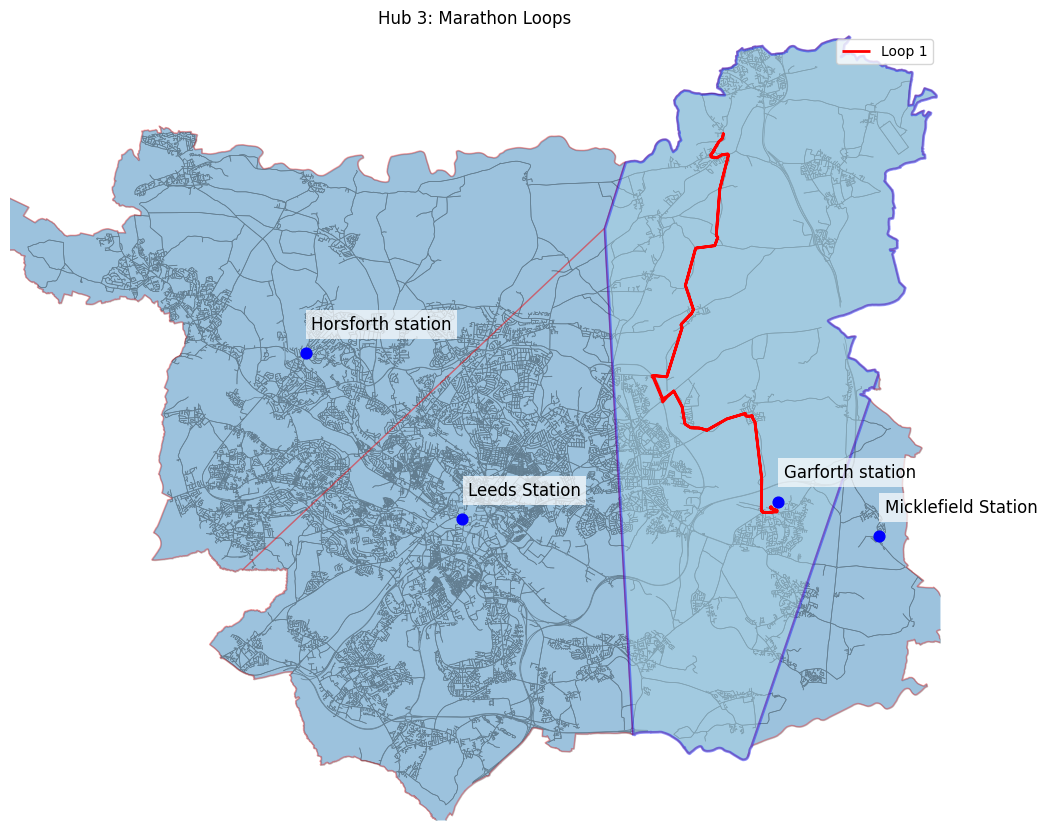

In [ ]:
#ONLY FOUND LOOPS FOR CELL 3 (Garforth station)
plot_loops_for_cell(
    cell_index=3,
    vor_gdf=vor_gdf,
    hubs_gdf=hubs_gdf,
    loops=loops_cell_3,
    leeds_boundary=leeds_boundary,
    G_proj=G_proj
)


In [ ]:
# import networkx as nx
# from shapely.geometry import LineString
# import geopandas as gpd
# from shapely.geometry import LineString, Point
# import random

# #path length and route geometry

# def path_length(G, path):
#     return sum(G[u][v][0]["length"] for u, v in zip(path[:-1], path[1:]))

# def route_to_linestring(G, route):
#     coords = [(G.nodes[n]["x"], G.nodes[n]["y"]) for n in route]
#     return LineString(coords)


# #Build a loop ≈ 42 km inside one cell
# #uses an OUT-AND-BACK path.
# def find_marathon_loop_in_cell(G_proj, cell_geom, hub_point,
#                                target_distance=42000, trials=10000):

#     # nodes inside cellsg
#     nodes_in_cell = [
#         n for n, data in G_proj.nodes(data=True)
#         if cell_geom.contains(Point(data["x"], data["y"]))
#     ]

#     G_vor = G_proj.subgraph(nodes_in_cell).copy() #G_vor is the subgraph containing only nodes in the Voronoi cell
#     if len(G_vor.nodes) == 0:
#         return None, None, None

#     # pick a start_node near one of the stations
#     start_node = ox.distance.nearest_nodes(G_proj, hub_point.x, hub_point.y)
#     if start_node not in G_vor.nodes: #checks that the start_node is inside the Voronoi cell of Leeds
#         start_node = list(G_vor.nodes())[0]


#     # - nodes_list: all possible target nodes inside the cell.
#     # - best_route: the best loop found so far.
#     # - best_len: its length.
#     # - best_diff: how close it is to 42 km (initially huge).
#     nodes_list = list(G_vor.nodes()) 
#     best_route, best_len, best_diff = None, None, 1e12

   
#     # For Each trial:
#     #     - Pick a random node inside the cell (target).
#     #     - Try to build a loop to it and back to the station (start_node).

#     for _ in range(trials): 
#         target = random.choice(nodes_list)

#         try:
#             out_path = nx.shortest_path(G_vor, start_node, target, weight="length") #computes shortest path from the station to the target
#         except nx.NetworkXNoPath:
#             continue
        
#         # - out_len: distance from hub → target.
#         # - total_len: out‑and‑back loop.
#         # - diff: how close the loop is to 42 km.
#         out_len = path_length(G_vor, out_path)
#         total_len = 2 * out_len  # out and back
#         diff = abs(total_len - target_distance)

#         # Conditions:
#             # - Loop must be at least 30 km (to avoid tiny loops).
#             # - Must be closer to 42 km than previous best.
#         # If it’s better:
#             # - Update the best loop.
#             # - Build the full loop by reversing the path back to the start:
#             # - out_path[::-1] reverses the list.
#             # - [1:] removes the duplicate start node.
#         if total_len > 38000 and diff < best_diff:
#             best_diff = diff
#             best_len = total_len
#             best_route = out_path + out_path[::-1][1:]

#     if best_route is None:
#         return None, None, None

#     return G_vor, best_route, best_len

#     # If no loop was found, return nothing.
#     # Otherwise return:
#     # - SG: the subgraph used
#     # - best_route: list of node IDs
#     # - best_len: loop length in metres




In [ ]:
# import random
# import geopandas as gpd

# successful_cells = []
# routes = []

# # Randomise the order of Voronoi cells
# all_indices = list(range(len(vor_gdf)))
# random.shuffle(all_indices)

# print("Testing cells in this random order:", all_indices)

# for i in all_indices:
#     cell_geom = vor_gdf.iloc[i].geometry
#     hub_point = hubs_gdf.iloc[i].geometry

#     # Skip invalid cells
#     if cell_geom is None or cell_geom.is_empty:
#         print(f"Cell {i}: INVALID geometry — skipping")
#         continue

#     # Try to build a marathon loop
#     G_vor, route, length_m = find_marathon_loop_in_cell(
#         G_proj,
#         cell_geom,
#         hub_point,
#         target_distance=42000,
#         trials=2000
#     )

#     if route is None:
#         print(f"Cell {i}: ❌ No marathon loop found")
#         continue

#     # Success!
#     print(f"Cell {i}: ✅ Marathon loop found ({length_m/1000:.2f} km)")
#     successful_cells.append(i)
#     geom = route_to_linestring(G_vor, route)
#     geom = geom.intersection(boundary_poly)

#     routes.append({
#         "cell_id": i,
#         "length_m": length_m,
#         "geometry": geom
#     })

#     # Stop once we have 2–3 successful cells
#     if len(successful_cells) >= 3:
#         break


# # Build GeoDataFrame if any routes succeeded
# if len(routes) == 0:
#     print("❌ No marathon routes found in any cell.")
# else:
#     routes_gdf = gpd.GeoDataFrame(routes, geometry="geometry", crs="EPSG:27700")
#     print("🎉 Successful cells:", successful_cells)

# #Cell 1 has a perfect 42,000 m loop


In [ ]:
# import matplotlib.pyplot as plt

# # Define a color for each successful cell
# color_map = {
#     #2: "red",
#     3: "green",
#     #0: "blue"
# }

# successful_ids = [3]
# successful_routes_gdf = routes_gdf[routes_gdf["cell_id"].isin(successful_ids)]

# fig, ax = plt.subplots(figsize=(12, 12))

# # Plot all Voronoi cells
# vor_gdf.plot(ax=ax, alpha=0.20, edgecolor="black", linewidth=1)

# # Highlight successful cells
# vor_gdf.loc[successful_ids].plot(
#     ax=ax, alpha=0.30, edgecolor="black", linewidth=2
# )

# # Plot each marathon route in its own color
# for cid in successful_ids:
#     subset = successful_routes_gdf[successful_routes_gdf["cell_id"] == cid]
#     subset.plot(
#         ax=ax,
#         color=color_map[cid],
#         linewidth=2.5,
#         label=f"Cell {cid} route ({subset.length_m.iloc[0]/1000:.1f} km)"
#     )

# # Plot hub points
# hubs_gdf.plot(
#     ax=ax, color="darkred", markersize=60, label="Hub points"
# )

# # Annotate hubs
# for idx, row in hubs_gdf.iterrows():
#     ax.annotate(
#         row["name"],
#         xy=(row.geometry.x, row.geometry.y),
#         xytext=(3, 3),
#         textcoords="offset points",
#         fontsize=10,
#         color="darkred"
#     )

# ax.set_title("Color‑coded Marathon Loops for Voronoi Cells 1, 2, and 0", fontsize=16)
# ax.legend()
# plt.show()




If for steps 3-4 there were cells with no such path, what different options could you
consider increasing the number of cells that include such paths? 

(Hint: think about the number and location of seed points; the size of the area under consideration; etc.) 

Choose one of such options, repeat steps 3-4, and report the results you obtain, explaining your reasoning. 

I want to - Relocate hubs using k-means to find places with the largest network density
- Pros: avoids “unlucky” hubs near edges or in sparse areas; cells become more balanced in area and network density.
- Cons: hubs may no longer correspond to real stations.

Why relocating hubs using k‑means helps
Your original hubs were real train stations, which is fine, but they produce Voronoi cells that are:
- uneven in size
- uneven in shape
- uneven in road‑network density
This is exactly why one of your cells failed to produce a marathon loop — it simply didn’t have enough “depth” (long enough shortest‑path distances) to support a 42 km out‑and‑back.
Using k‑means clustering on the road‑network nodes (or on the Leeds boundary) gives you:
- four hubs that are spatially balanced
- four Voronoi cells of similar area
- cells that avoid being squeezed against the Leeds boundary
- cells with more even road‑network coverage
This increases the probability that each cell contains at least one node ≥21 km from the hub, which is the minimum needed for a 42 km out‑and‑back loop.



In [374]:
def kmeans_voronoi_maker(vor, radius=1e6):
    new_regions = [] 
    new_vertices = vor.vertices.tolist() # Start with the existing Voronoi vertices (will append new ones)
    center = vor.points.mean(axis=0)  # Compute the centroid of all input points (used to orient infinite rays)

    # Build a mapping of ridges for each point:
    # For each point p1, store all ridges connecting p1 to p2,
    # along with the vertex indices (v1, v2) of that ridge.
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # Build a finite region for each point in the SAME ORDER
    # as the original Voronoi diagram.
    for p1 in range(len(vor.points)):
        region_index = vor.point_region[p1]
        region = vor.regions[region_index]

        if -1 not in region:
            new_regions.append(region)
            continue

        # Rebuild infinite region by extending its infinite edges
        ridges = all_ridges[p1]
        new_region = [v for v in region if v != -1] # Start with all finite vertices in the region
        # Loop through all ridges touching this point
        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0:  # If both vertices are finite, skip
                continue
            # Compute direction of the infinite ray:
            # perpendicular to the line between p1 and p2
            t = vor.points[p2] - vor.points[p1]
            t = np.array([-t[1], t[0]]) # perpendicular vector
            midpoint = vor.points[[p1, p2]].mean(axis=0) # Midpoint of the ridge
            direction = np.sign(np.dot(midpoint - center, t)) * t # Choose direction that points outward from the center
            far_point = vor.vertices[v2] + direction * radius  # Extend the finite vertex v2 far outward along this direction

            new_vertices.append(far_point.tolist()) # Add this new vertex to the global vertex list
            new_region.append(len(new_vertices) - 1) # Add index of this new vertex to the region

        new_regions.append(new_region) # Store the completed finite region
        
    # Return all finite regions and the updated vertex array
    return new_regions, np.asarray(new_vertices)


In [375]:
import numpy as np
from sklearn.cluster import KMeans
import geopandas as gpd
from shapely.geometry import Point

# Extract road‑network node coordinates from G_proj
node_coords = np.array([
    (data["x"], data["y"])
    for _, data in G_proj.nodes(data=True)
])

#run k-means to find 4 balanced hub locations
k = 4  # number of hubs you want
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(node_coords)

centroids = kmeans.cluster_centers_ #<-- contains 4 optimally spaced hub locations


#convert centroids into a GeoDataFrame of new hubs
hub_points = [Point(x, y) for x, y in centroids]

hubs_kmeans_gdf = gpd.GeoDataFrame(
    {"hub_id": range(k)},
    geometry=hub_points,
    crs="EPSG:27700"
)

# 1. Extract hub coordinates
#coords = np.array([(p.x, p.y) for p in hubs_kmeans_gdf.geometry])
coords = np.array([(p.x, p.y) for p in hubs_kmeans_gdf.geometry])

# 2. Build Voronoi diagram
vor = Voronoi(coords)

# 3. Reconstruct finite polygons
regions, vertices = kmeans_voronoi_maker(vor)
#print(len(regions))

# 4. Correctly map each hub to its region
hub_regions = [regions[i] for i in range(len(coords))]
#print(len(hub_regions))

# 5. Build polygons
polygons = [Polygon(vertices[r]) for r in regions]
#print(len(polygons))

# 6. Build GeoDataFrame
vor_gdf = gpd.GeoDataFrame(
    {"hub_id": range(len(polygons))},
    geometry=polygons,
    crs="EPSG:27700"
)

# 7. Clip to Leeds boundary
vor_gdf = gpd.overlay(vor_gdf, leeds_boundary, how="intersection")
vor_gdf = vor_gdf.reset_index(drop=True)



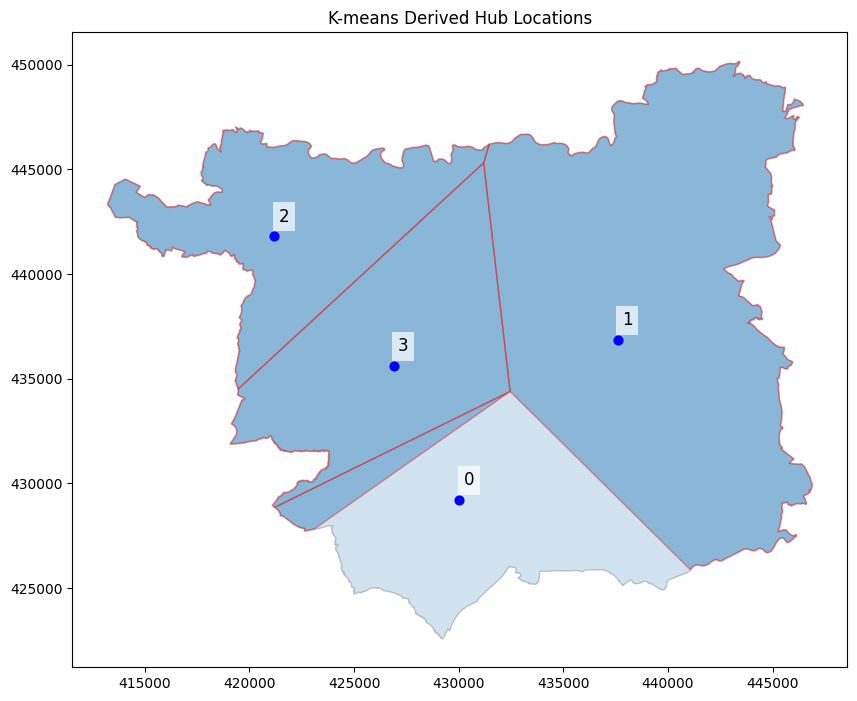

In [376]:
ax = leeds_boundary.plot(figsize=(10,10), alpha=0.2, edgecolor="black")
hubs_kmeans_gdf["label"] = hubs_kmeans_gdf.index.astype(str)

vor_gdf.plot(ax=ax, alpha=0.4, edgecolor="red")
hubs_kmeans_gdf.plot(ax=ax, color="blue", markersize=40)
for idx, row in hubs_kmeans_gdf.iterrows(): #Label Each Dot
    x, y = row.geometry.x, row.geometry.y
    ax.text(
        x + 200, y + 500,  #offset so the dot is visible
        row["label"],
        fontsize=12,
        ha="left",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

plt.title("K-means Derived Hub Locations")
plt.show()



In [377]:

#CODE FOR PLOTTING THESE LOOPS ON THE KMEANS DIAGRAM
import matplotlib.pyplot as plt
import geopandas as gpd

def KMeans_plot_loops_for_cell(cell_index, vor_gdf, hubs_kmeans_gdf, loops, leeds_boundary, G_proj):

    fig, ax = plt.subplots(figsize=(12, 12))

    # 1. Leeds boundary
    leeds_boundary.plot(ax=ax, alpha=0.2, edgecolor="black")

    # 2. Road network (NEW)
    ox.plot_graph(
        G_proj,
        ax=ax,
        node_size=0,
        edge_color="gray",
        edge_linewidth=0.5,
        show=False,
        close=False
    )

    # 3. Voronoi cells
    vor_gdf.plot(ax=ax, alpha=0.3, edgecolor="red")

    # 4. Highlight selected cell
    cell_geom = vor_gdf.geometry.iloc[cell_index]
    gpd.GeoSeries([cell_geom], crs=vor_gdf.crs).plot(
        ax=ax, color="lightblue", alpha=0.4, edgecolor="blue", linewidth=2
    )

    # 5. Plot loops (each in different colour)
    colours = ["red", "green", "purple", "orange", "brown", "cyan"]
    for i, loop in enumerate(loops):
        gpd.GeoSeries([loop["geometry"]], crs=vor_gdf.crs).plot(
            ax=ax, color=colours[i % len(colours)], linewidth=2, label=f"Loop {i+1}"
        )

    # 6. Plot hubs
    hubs_kmeans_gdf.plot(ax=ax, color="blue", markersize=60)

    # 7. Label hubs
    for idx, row in hubs_kmeans_gdf.iterrows():
        x, y = row.geometry.x, row.geometry.y
        ax.text(
            x + 200, y + 200,
            str(idx),
            fontsize=12,
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
        )

    ax.set_title(f"K-means Hub {cell_index}: Marathon Loops")
    ax.set_axis_off()
    ax.legend()
    plt.show()


In [ ]:
hubs_kmeans_gdf.describe

<bound method NDFrame.describe of    hub_id                       geometry label
0       0  POINT (430035.945 429228.941)     0
1       1  POINT (437594.409 436866.531)     1
2       2   POINT (421184.12 441819.247)     2
3       3  POINT (426886.236 435628.382)     3>

In [ ]:
#Valid Marathon loops For Cell 0
cell_index = 0   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_kmeans_gdf.geometry.iloc[cell_index]

kmeans_loops_cell_0 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(kmeans_loops_cell_0)} loops in cell {cell_index}")

for loop in kmeans_loops_cell_0:
    print(loop["length"])

Found 0 loops in cell 0


In [ ]:
#Valid Marathon loops For Cell 1
cell_index = 1   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_kmeans_gdf.geometry.iloc[cell_index]

kmeans_loops_cell_1 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(kmeans_loops_cell_1)} loops in cell {cell_index}")

for loop in kmeans_loops_cell_1:
    print(loop["length"])

# Found 1 loops in cell 1
# 38280.79709410579

Found 1 loops in cell 1
38280.79709410579


In [ ]:
#Valid Marathon loops For Cell 2
cell_index = 2   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_kmeans_gdf.geometry.iloc[cell_index]

kmeans_loops_cell_2 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(kmeans_loops_cell_2)} loops in cell {cell_index}")

for loop in kmeans_loops_cell_2:
    print(loop["length"])

Found 0 loops in cell 2


In [ ]:
#Valid Marathon loops For Cell 3
cell_index = 3   # pick any Voronoi cell
cell_geom = vor_gdf.geometry.iloc[cell_index]
hub_point = hubs_kmeans_gdf.geometry.iloc[cell_index]

kmeans_loops_cell_3 = find_multiple_loops_in_cell(G_proj, cell_geom, hub_point)

print(f"Found {len(kmeans_loops_cell_3)} loops in cell {cell_index}")

for loop in kmeans_loops_cell_3:
    print(loop["length"])

Found 0 loops in cell 3


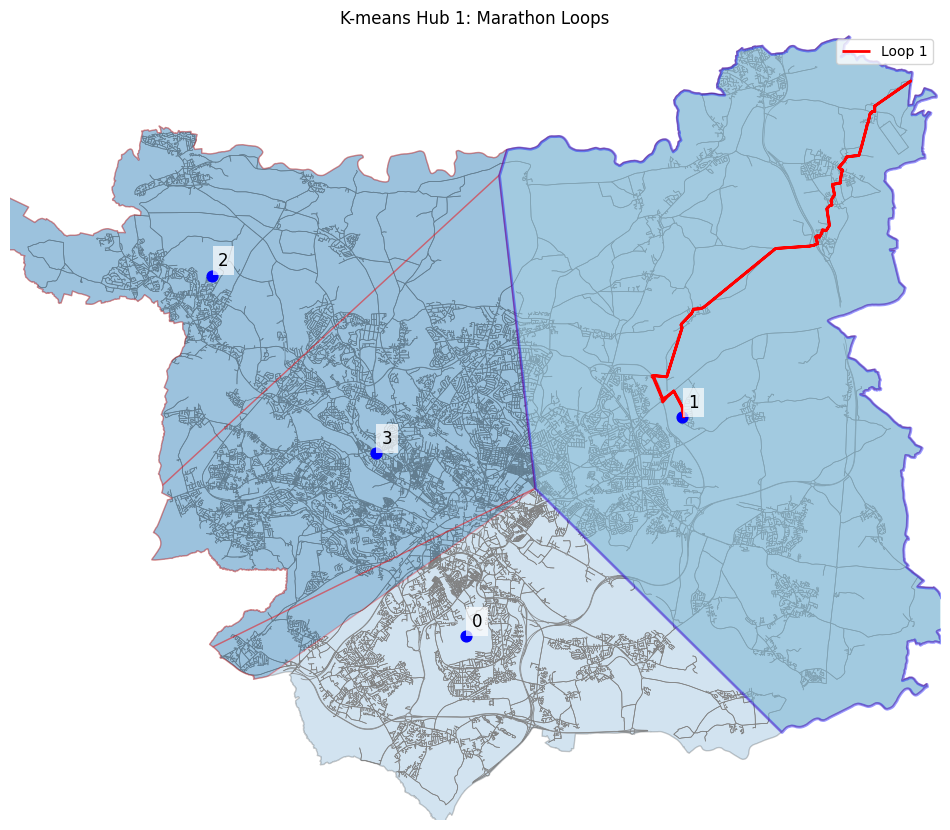

In [ ]:
KMeans_plot_loops_for_cell(
    cell_index=1,
    vor_gdf=vor_gdf,
    hubs_kmeans_gdf=hubs_kmeans_gdf,
    loops=kmeans_loops_cell_1,
    leeds_boundary=leeds_boundary,
    G_proj=G_proj
)


After experimenting with an alternative approach that replaced predefined transportation hubs with K means centroids derived from the spatial distribution of the Leeds road network, the overall feasibility of generating marathon length loops did not improve. Although K means provides a data driven way to position hub points in areas of high network density, the resulting Voronoi cells did not consistently contain enough connected road length to support a 42 km route. In practice, the cell corresponding to the Garforth area (cell 3) remained the only region capable of producing multiple viable long distance loops. This suggests that the underlying road structure, rather than the choice of hub placement method, is the dominant factor in determining whether a cell can support a marathon scale circuit. The Garforth region simply offers a more extensive and better connected road network, making it inherently more suitable for long form race planning than other parts of the study area.

In [ ]:
# import random
# import geopandas as gpd

# successful_cells = []
# routes = []

# # Randomise the order of Voronoi cells
# all_indices = list(vor_gdf["hub_id"])
# random.shuffle(all_indices)

# print("Testing cells in this random order:", all_indices)

# for hub_id in all_indices:

#     # Get the correct Voronoi cell for this hub
#     cell_geom = vor_gdf.loc[vor_gdf["hub_id"] == hub_id].geometry.values[0]

#     # Get the correct hub point
#     hub_point = hubs_kmeans_gdf.loc[hubs_kmeans_gdf["hub_id"] == hub_id].geometry.values[0]

#     # Skip invalid cells
#     if cell_geom is None or cell_geom.is_empty:
#         print(f"Hub {hub_id}: INVALID geometry — skipping")
#         continue

#     # Try to build a marathon loop
#     G_vor, route, length_m = find_marathon_loop_in_cell(
#         G_proj,
#         cell_geom,
#         hub_point,
#         target_distance=42000,
#         trials=5000
#     )

#     if route is None:
#         print(f"Hub {hub_id}: ❌ No marathon loop found")
#         continue

#     # Success!
#     print(f"Hub {hub_id}: ✅ Marathon loop found ({length_m/1000:.2f} km)")
#     successful_cells.append(hub_id)

#     geom = route_to_linestring(G_vor, route)
#     geom = geom.intersection(boundary_poly)

#     routes.append({
#         "cell_id": hub_id,
#         "length_m": length_m,
#         "geometry": geom
#     })

#     # Stop once we have 2–3 successful cells
#     if len(successful_cells) >= 3:
#         break

# # Build GeoDataFrame if any routes succeeded
# if len(routes) == 0:
#     print("❌ No marathon routes found in any cell.")
# else:
#     routes_gdf = gpd.GeoDataFrame(routes, geometry="geometry", crs="EPSG:27700")
#     print("🎉 Successful cells:", successful_cells)


In [ ]:
# import matplotlib.pyplot as plt

# # Define a color for each successful cell
# color_map = {
#     1: "blue",
#     #2: "yellow",
#     #3: "red",
#     #0: "green",

# }

# successful_ids = [1]
# successful_routes_gdf = routes_gdf[routes_gdf["cell_id"].isin(successful_ids)]

# fig, ax = plt.subplots(figsize=(12, 12))

# # Plot all Voronoi cells
# vor_gdf.plot(ax=ax, alpha=0.20, edgecolor="black", linewidth=1)

# # Highlight successful cells
# vor_gdf.loc[successful_ids].plot(
#     ax=ax, alpha=0.30, edgecolor="black", linewidth=2
# )

# # Plot each marathon route in its own color
# for cid in successful_ids:
#     subset = successful_routes_gdf[successful_routes_gdf["cell_id"] == cid]
#     subset.plot(
#         ax=ax,
#         color=color_map[cid],
#         linewidth=2.5,
#         label=f"Cell {cid} route ({subset.length_m.iloc[0]/1000:.1f} km)"
#     )

# # Plot k-means hub points
# hubs_kmeans_gdf.plot(
#     ax=ax, color="darkred", markersize=60, label="Hub points"
# )

# # OPTIONAL: annotate hubs with their hub_id instead of names
# for idx, row in hubs_kmeans_gdf.iterrows():
#     ax.annotate(
#         f"Hub {row['hub_id']}",
#         xy=(row.geometry.x, row.geometry.y),
#         xytext=(3, 3),
#         textcoords="offset points",
#         fontsize=10,
#         color="darkred"
#     )

# ax.set_title("K-means Hubs: Marathon Loops for Voronoi Cells 2 and 3", fontsize=16)
# ax.legend()
# plt.show()
